In [2]:
from core.io import load_parquet
from core.validation import validate_play
from core.scoring import score_play
from optimizer.solve import solve_all_gameweeks
from optimizer.pruning import prune_by_score_per_price, prune_by_three_score_per_price
import time
import matplotlib.pyplot as plt

In [3]:
stats = load_parquet("player_data.parquet")
small_stats = stats[stats["gw"]<=22]

In [39]:
scores = []
times = []
tresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
for treshold in tresholds:
    treshold
    pruned_keys = prune_by_score_per_price(small_stats, threshold=treshold)
    print(len(pruned_keys))
    tic = time.time()
    picks, chips = solve_all_gameweeks(stats=small_stats,pruned_keys=pruned_keys)
    times.append(time.time()-tic)
    errors = validate_play(picks, chips, small_stats)
    if errors:
        print("Invalid play found:")
        for e in errors:
            print(f"  - {e}")
    result = score_play(picks, chips, small_stats)
    scores.append(result['total'])

4948
Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1185G7 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2866236 - for non-commercial use only - registered to vm___@kth.se
Optimize a model with 347367 rows, 149612 columns and 931472 nonzeros (Max)
Model fingerprint: 0x16e8f256
Model has 26997 linear objective coefficients
Variable types: 0 continuous, 149612 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 9e+02]
  Objective range  [1e+00, 2e+01]
  Bounds range     [1e+00, 1e+02]
  RHS range        [1e+00, 1e+03]

Presolve removed 249891 rows and 85426 columns
Presolve time: 4.04s
Presolved: 97476 rows, 64186 columns, 295059 nonzeros
Variable types: 0 continuous, 64186 integer (49270 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing primal log only...


Root simple

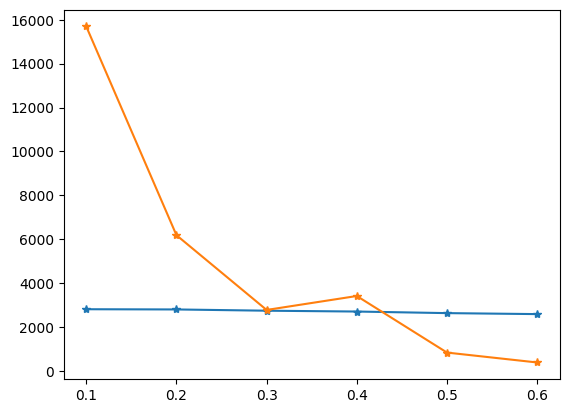

In [40]:
plt.plot(tresholds[0:6], scores,'*-')
plt.plot(tresholds[0:6], times[0:6],'*-')

Text(0.5, 0, 'time (seconds)')

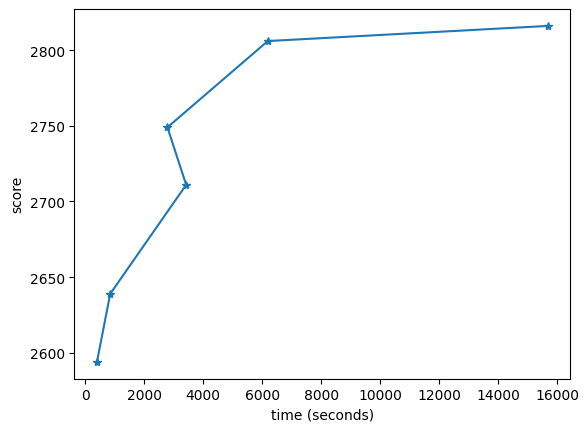

In [44]:
plt.plot(times[0:6],scores,'*-')
plt.ylabel("score")
plt.xlabel("time (seconds)")

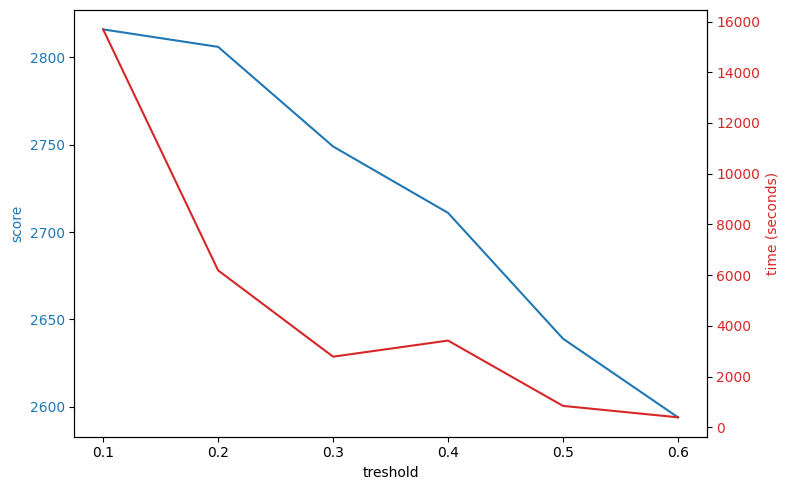

In [47]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Left axis
color1 = 'tab:blue'
ax1.set_xlabel('treshold')
ax1.set_ylabel('score', color=color1)
line1, = ax1.plot(tresholds, scores, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Right axis, sharing the same x-axis
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('time (seconds)', color=color2)
line2, = ax2.plot(tresholds, times, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Combined legend (optional, since each axis has its own by default)
#ax1.legend([line1, line2], ['Y1', 'Y2'], loc='upper left')

fig.tight_layout()
plt.show()

In [37]:
small_stats = stats[stats["gw"]<=22]
pruned_keys = prune_by_score_per_price(small_stats, threshold=0.6)
print(len(pruned_keys))
picks, chips = solve_all_gameweeks(stats=small_stats,pruned_keys=pruned_keys)


8118
Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1185G7 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2866236 - for non-commercial use only - registered to vm___@kth.se
Optimize a model with 353707 rows, 149612 columns and 937812 nonzeros (Max)
Model fingerprint: 0xb7bbb866
Model has 26997 linear objective coefficients
Variable types: 0 continuous, 149612 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 9e+02]
  Objective range  [1e+00, 2e+01]
  Bounds range     [1e+00, 1e+02]
  RHS range        [1e+00, 1e+03]

Presolve removed 295533 rows and 119684 columns
Presolve time: 0.40s
Presolved: 58174 rows, 29928 columns, 166679 nonzeros
Variable types: 0 continuous, 29928 integer (22133 binary)
Performing another presolve...
Presolve removed 32350 rows and 10339 columns
Presolve time: 0.84s

Roo

In [10]:
pruned = prune_by_score_per_price(small_stats, threshold= 0.2)
new_pruned = prune_by_three_score_per_price(small_stats, threshold=0.4)
print(len(pruned))
print(len(new_pruned))
print(sorted(new_pruned)[:10])

5877
4942
[(1, 5), (1, 6), (1, 7), (1, 8), (2, 2), (2, 3), (2, 7), (2, 8), (2, 9), (2, 10)]


In [4]:
new_pruned = prune_by_three_score_per_price(small_stats, threshold=1.45)
picks, chips = solve_all_gameweeks(stats=small_stats,pruned_keys=new_pruned)

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1185G7 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2866236 - for non-commercial use only - registered to vm___@kth.se
Optimize a model with 353391 rows, 149612 columns and 937496 nonzeros (Max)
Model fingerprint: 0x4f428357
Model has 26997 linear objective coefficients
Variable types: 0 continuous, 149612 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 9e+02]
  Objective range  [1e+00, 2e+01]
  Bounds range     [1e+00, 1e+02]
  RHS range        [1e+00, 1e+03]

Presolve removed 293991 rows and 119197 columns
Presolve time: 0.32s
Presolved: 59400 rows, 30415 columns, 168639 nonzeros
Variable types: 0 continuous, 30415 integer (22493 binary)
Performing another presolve...
Presolve removed 32406 rows and 10801 columns
Presolve time: 0.97s

Root rel

In [5]:
scores = []
times = []
tresholds = [0.4, 0.6, 0.8, 1, 1.2, 1.45]
for treshold in tresholds:
    treshold
    pruned_keys = prune_by_three_score_per_price(small_stats, threshold=treshold)
    print(len(pruned_keys))
    tic = time.time()
    picks, chips = solve_all_gameweeks(stats=small_stats,pruned_keys=pruned_keys)
    times.append(time.time()-tic)
    errors = validate_play(picks, chips, small_stats)
    if errors:
        print("Invalid play found:")
        for e in errors:
            print(f"  - {e}")
    result = score_play(picks, chips, small_stats)
    scores.append(result['total'])

4942
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2866236
Read parameters from file gurobi.env
Academic license 2866236 - for non-commercial use only - registered to vm___@kth.se
Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1185G7 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2866236 - for non-commercial use only - registered to vm___@kth.se
Optimize a model with 347355 rows, 149612 columns and 931460 nonzeros (Max)
Model fingerprint: 0xc0b0bdfc
Model has 26997 linear objective coefficients
Variable types: 0 continuous, 149612 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 9e+02]
  Objective range  [1e+00, 2e+01]
  Bounds range     [1e+00, 1e+02]
  RHS range        [1e+00, 1e+03]

Presolve removed 256428 rows and 89136 columns (presolve time = 5s)...
P

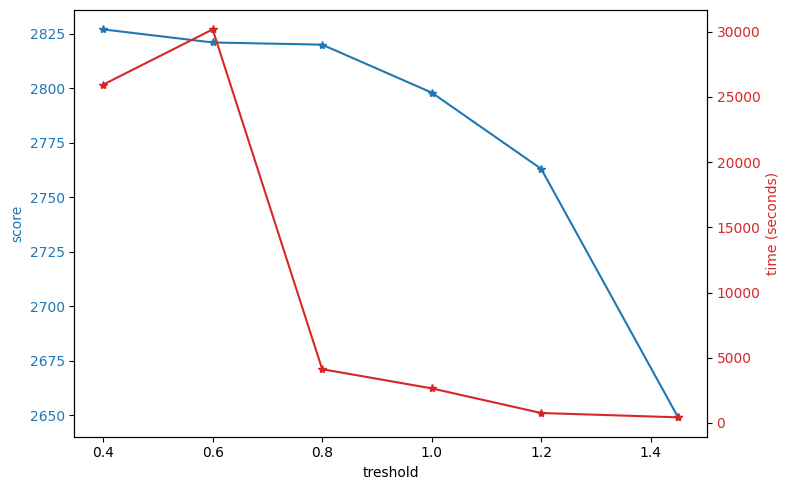

In [13]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Left axis
color1 = 'tab:blue'
ax1.set_xlabel('treshold')
ax1.set_ylabel('score', color=color1)
line1, = ax1.plot(tresholds, scores, '*-', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Right axis, sharing the same x-axis
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('time (seconds)', color=color2)
line2, = ax2.plot(tresholds, times,'*-', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Combined legend (optional, since each axis has its own by default)
#ax1.legend([line1, line2], ['Y1', 'Y2'], loc='upper left')

fig.tight_layout()
plt.show()